# Langkah 5: Visualisasi Knowledge Graph

- **Input**: `03_04_pembangunan_kg/triplets_all.tsv`, `netflix_titles.csv`
- **Output**: `05_visualisasi/visualisasi/kg_visualization.png`

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
from pathlib import Path

## Konfigurasi Path

In [26]:
BASE_DIR      = Path(".").resolve()
TRIPLETS_TSV  = BASE_DIR / "03_04_user_triplets_knowledge_graph" / "kg_merged_with_user.tsv"
NETFLIX_CSV   = BASE_DIR / "Data_Netflix" / "netflix_titles.csv"
OUT_DIR       = BASE_DIR / "05_visualisasi" / "visualisasi"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Warna per tipe node
COLOR_MAP = {
    "show":         "#4C9BE8",
    "has_actor":    "#E8924C",
    "has_director": "#9B59B6",
    "has_genre":    "#2ECC71",
    "produced_in":  "#E74C3C",
    "has_rating":   "#F1C40F",
    "liked":      "#FFFFFF",
}

Baca Data

In [22]:
df_triplets = pd.read_csv(
    TRIPLETS_TSV, sep="\t", header=None,
    names=["head", "relation", "tail"], dtype=str
)
print(f"{len(df_triplets):,} triplets | {df_triplets['relation'].nunique()} relasi")
df_triplets.head()

19,485 triplets | 6 relasi


,head,relation,tail
0,s28,has_actor,Adam Sandler
1,s28,has_actor,Kevin James
2,s28,has_actor,Chris Rock
3,s28,has_actor,David Spade
4,s28,has_actor,Rob Schneider


In [23]:
# Mapping show_id -> title
id_to_title = {}
if NETFLIX_CSV.exists():
    df_meta = pd.read_csv(NETFLIX_CSV, dtype=str, usecols=["show_id", "title"])
    df_meta["show_id"] = df_meta["show_id"].astype(str).str.strip()
    df_meta["title"]   = df_meta["title"].astype(str).str.strip()
    id_to_title = dict(zip(df_meta["show_id"], df_meta["title"]))
    print(f"{len(id_to_title):,} entri (show_id -> title)")
else:
    print(f"[WARN] {NETFLIX_CSV.name} tidak ditemukan — label akan menggunakan show_id")

8,807 entri (show_id -> title)


Fungsi Visualisasi

In [24]:
def _short(label: str, max_len: int = 18) -> str:
    """Potong label yang terlalu panjang."""
    return label[:max_len] + "\u2026" if len(label) > max_len else label


def visualize_kg(
    df_triplets: pd.DataFrame,
    id_to_title: dict,
    n_shows: int = 30,
    out_path: Path = None,
):
    # Pilih n_shows dengan triplet terbanyak
    sample_shows = (
        df_triplets[df_triplets["relation"] == "has_genre"]["head"]
        .value_counts()
        .head(n_shows)
        .index.tolist()
    )
    df_vis = df_triplets[df_triplets["head"].isin(sample_shows)]

    # Bangun graf
    G = nx.DiGraph()
    for _, row in df_vis.iterrows():
        G.add_node(row["head"], node_type="show")
        G.add_node(row["tail"], node_type=row["relation"])
        G.add_edge(row["head"], row["tail"], relation=row["relation"])

    node_colors = [
        COLOR_MAP.get(G.nodes[n].get("node_type", "show"), "#95A5A6")
        for n in G.nodes()
    ]
    node_sizes = [
        650 if G.nodes[n].get("node_type") == "show" else 220
        for n in G.nodes()
    ]

    # Layout & kanvas
    fig, ax = plt.subplots(figsize=(24, 16))
    ax.set_facecolor("#1A1A2E")
    fig.patch.set_facecolor("#1A1A2E")

    try:
        pos = nx.spring_layout(G, k=2.5, iterations=60, seed=42)
    except Exception:
        pos = nx.random_layout(G, seed=42)

    # Gambar nodes & edges
    nx.draw_networkx_nodes(G, pos, node_color=node_colors,
                           node_size=node_sizes, alpha=0.92, ax=ax)
    nx.draw_networkx_edges(G, pos, edge_color="#888899", alpha=0.35,
                           arrows=True, arrowsize=8, width=0.6,
                           connectionstyle="arc3,rad=0.1", ax=ax)

    # Label node Show (judul film)
    show_labels = {
        n: _short(id_to_title.get(n, n), max_len=18)
        for n in G.nodes() if G.nodes[n].get("node_type") == "show"
    }
    # Label node Tail (aktor, genre, negara, dll.)
    tail_labels = {
        n: _short(n, max_len=14)
        for n in G.nodes() if G.nodes[n].get("node_type") != "show"
    }

    nx.draw_networkx_labels(G, pos, labels=show_labels,
                            font_size=6.5, font_color="white",
                            font_weight="bold", ax=ax)
    nx.draw_networkx_labels(G, pos, labels=tail_labels,
                            font_size=5, font_color="#CCCCCC",
                            font_weight="normal", ax=ax)

    # Legenda
    legend_elements = [
        mpatches.Patch(color=COLOR_MAP["show"],         label="Show (Film/TV)"),
        mpatches.Patch(color=COLOR_MAP["has_actor"],    label="Aktor — has_actor"),
        mpatches.Patch(color=COLOR_MAP["has_director"], label="Sutradara — has_director"),
        mpatches.Patch(color=COLOR_MAP["has_genre"],    label="Genre — has_genre"),
        mpatches.Patch(color=COLOR_MAP["produced_in"],  label="Negara — produced_in"),
        mpatches.Patch(color=COLOR_MAP["has_rating"],   label="Rating — has_rating"),
        mpatches.Patch(color=COLOR_MAP["liked"],      label="Like — liked"),
    ]
    ax.legend(handles=legend_elements, loc="upper left",
              facecolor="#2C2C54", labelcolor="white",
              fontsize=9, framealpha=0.85)
    ax.set_title(
        f"Knowledge Graph — Sampel {n_shows} Show Netflix Teratas  "
        f"(label: judul film, ID internal: show_id)",
        fontsize=13, color="white", pad=14, fontweight="bold"
    )
    ax.axis("off")
    plt.tight_layout()

    if out_path:
        plt.savefig(out_path, dpi=150, bbox_inches="tight",
                    facecolor=fig.get_facecolor())
        print(f"Visualisasi disimpan: {out_path}")

    plt.show()
    plt.close(fig)

## Jalankan Visualisasi

Visualisasi disimpan: D:\Prototipe-Skripsi\Preprocessing\05_visualisasi\visualisasi\kg_visualization.png


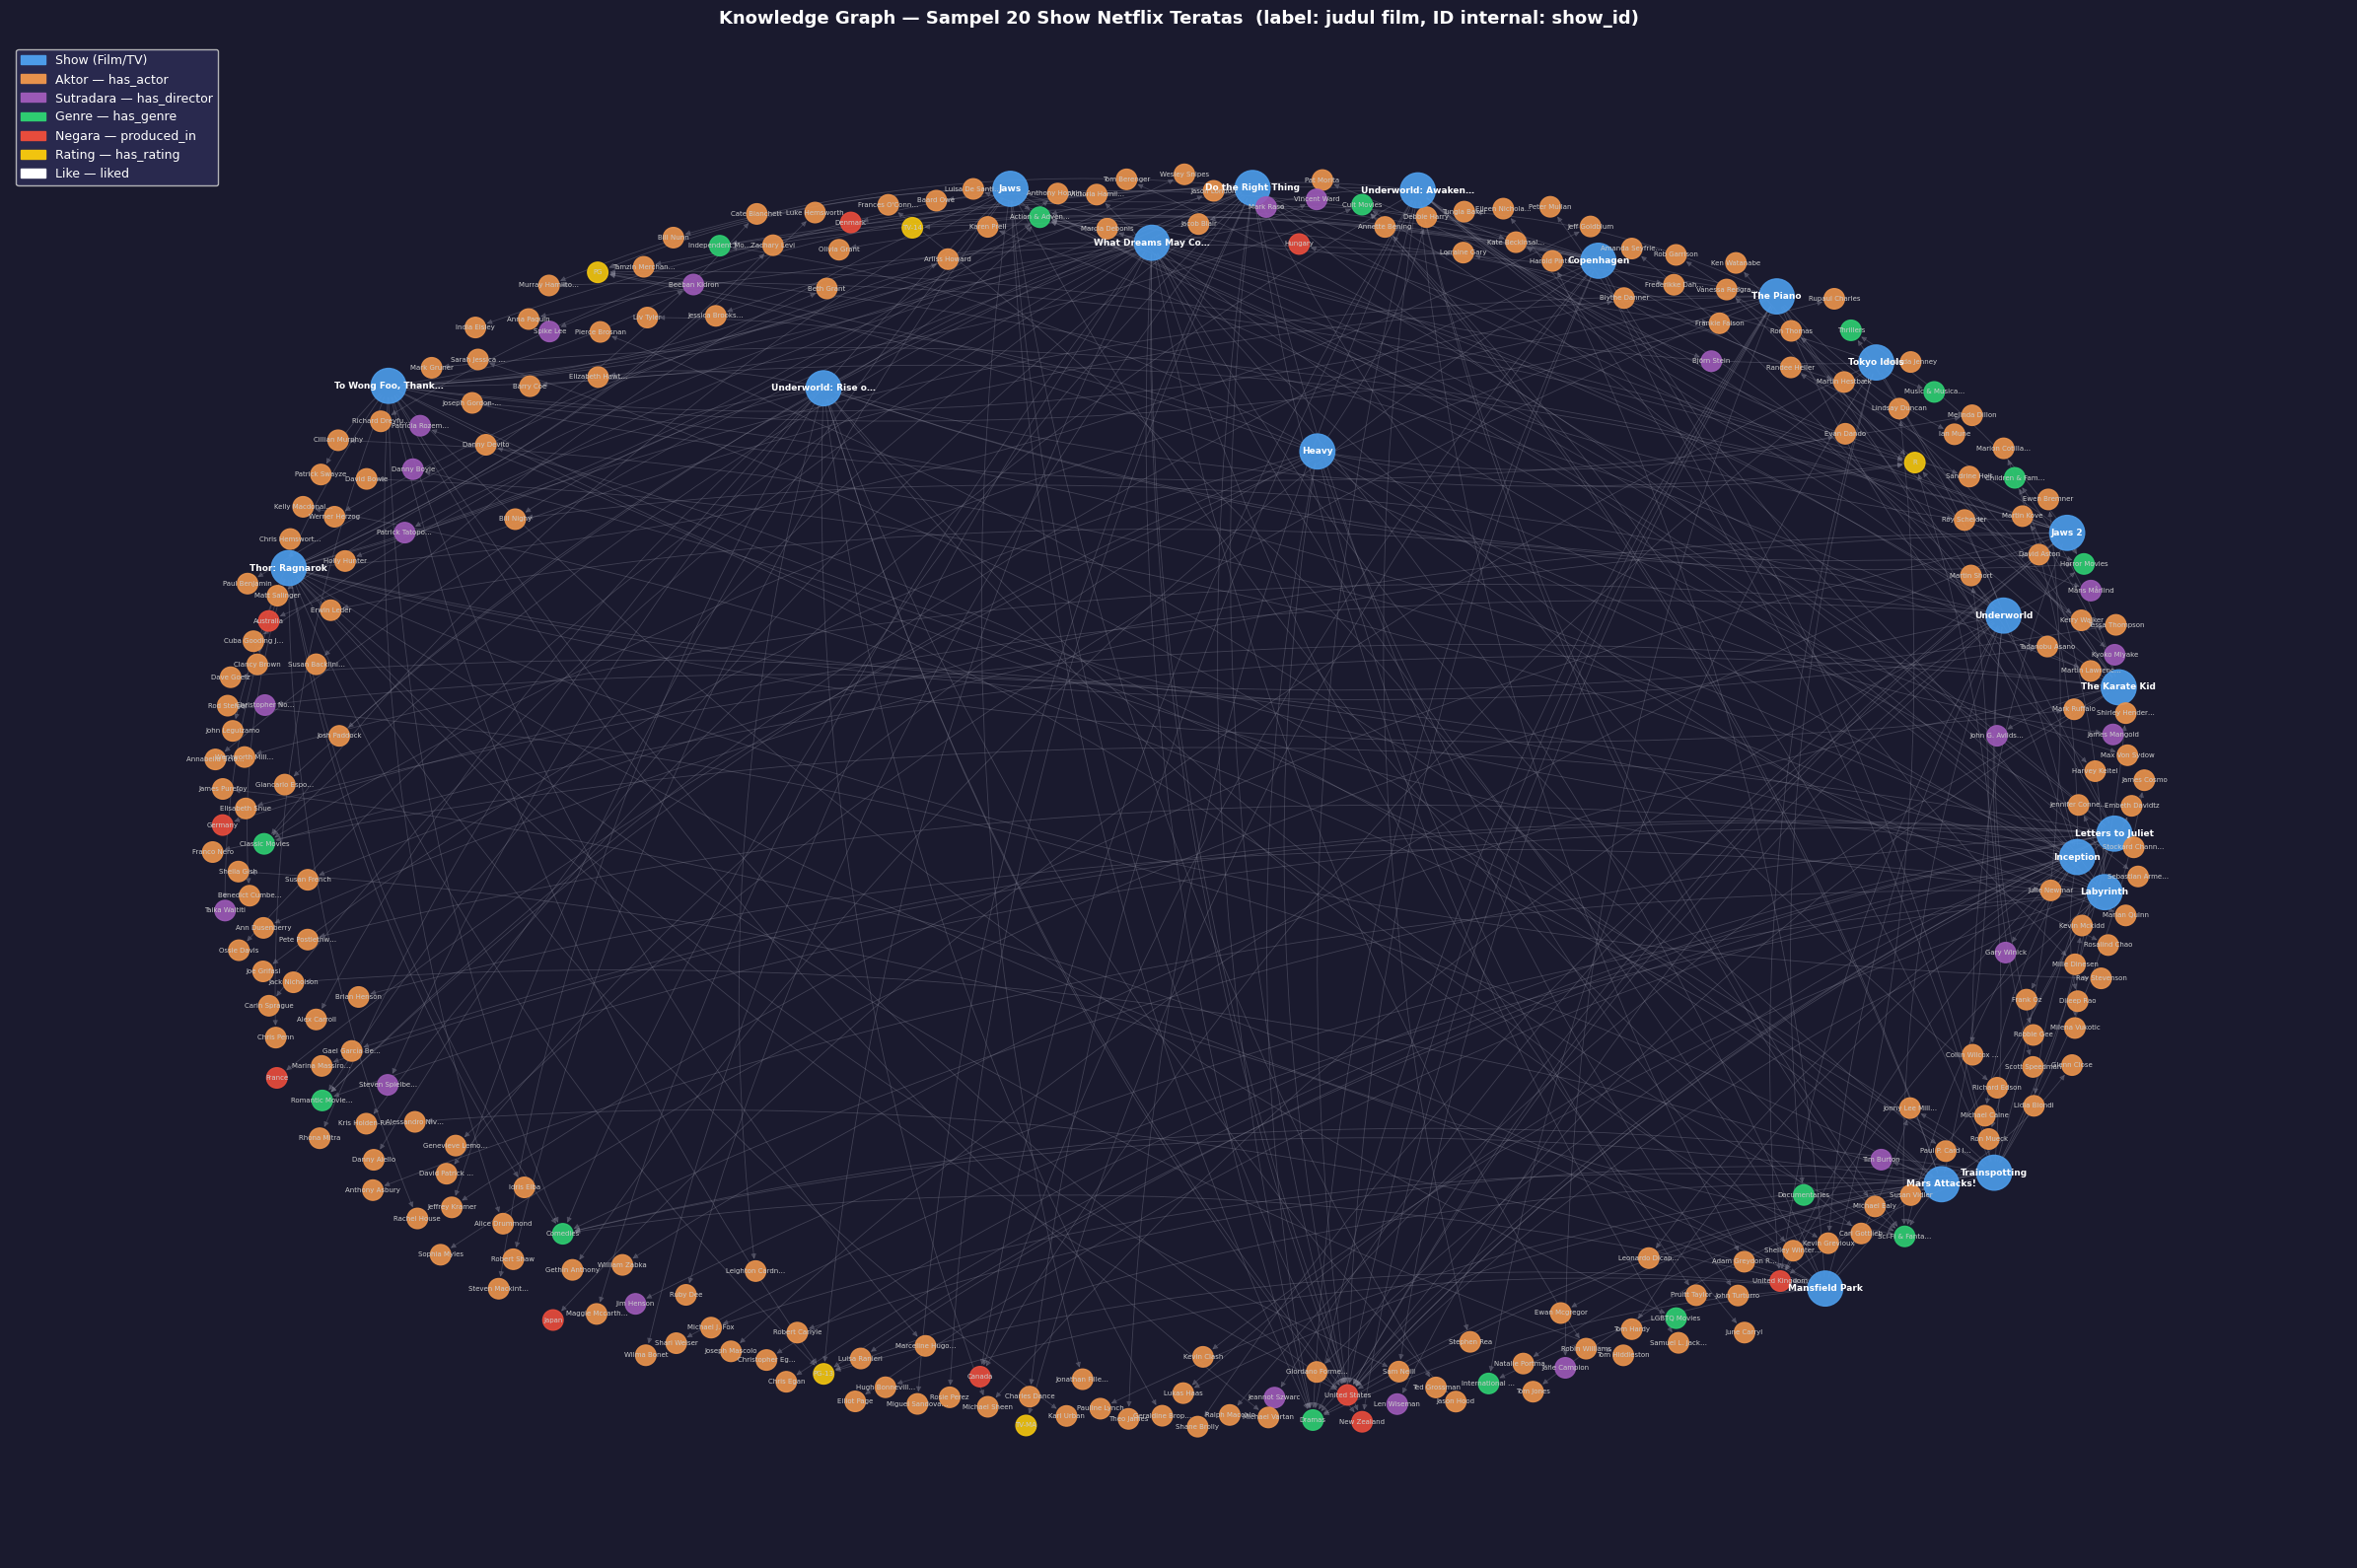

In [27]:
out_png = OUT_DIR / "kg_visualization.png"
visualize_kg(df_triplets, id_to_title=id_to_title, n_shows=20, out_path=out_png)